# Task 3 — Static Malware Analysis of PE Files
**Module:** Data Science for Cyber Security  
**Task:** Static analysis of Windows Portable Executable (PE) files using `pefile`, string forensics, heuristic classification, and supervised machine learning.  

---
### Notebook Overview
| Section | Description | Marks |
|---------|-------------|-------|
| Setup | Load PE files with pefile | — |
| Task 1 | PE Section Header Analysis | 2 |
| Task 2 | Import Table Analysis (DLLs & Functions) | 2 |
| Task 3 | String Extraction & Forensics | 4 |
| Task 4 | Suspicious API Heuristic Classification | 4 |
| Task 5 | Machine Learning Classification | 8 |

---

> **Core reference:** The static analysis methodology follows [Sikorski & Honig, 2012]. PE file parsing is performed with the `pefile` library [Carrera, 2007].

## Setup
Install `pefile` if not already installed, then load all three PE samples into a dictionary for reuse throughout the notebook.

In [1]:
# Install pefile library (runs silently if already installed)
!pip install pefile --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import string
from collections import Counter

# ── Third-party ───────────────────────────────────────────────────────────────
import pefile
import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn as sns

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.tree              import DecisionTreeClassifier
from sklearn.neural_network    import MLPClassifier
from sklearn.metrics           import (accuracy_score,
                                        classification_report,
                                        confusion_matrix,
                                        precision_recall_fscore_support)

# ── Global style ──────────────────────────────────────────────────────────────
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# ── Output directory (same folder as notebook) ────────────────────────────────
OUTPUT_DIR = os.path.dirname(os.path.abspath('__file__'))
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [3]:
# ── Paths to PE samples (root workspace folder, one level above Task3/) ───────
BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..') 

pe_paths = {
    'File1': os.path.join(BASE_DIR, 'File1.task3'),
    'File2': os.path.join(BASE_DIR, 'File2.task3'),
    'File3': os.path.join(BASE_DIR, 'File3.task3'),
}

pe_objects = {}   # will hold successfully parsed pefile.PE objects

for name, path in pe_paths.items():
    try:
        pe = pefile.PE(path)
        pe_objects[name] = pe
        print(f'[OK]    {name} loaded from {path}')
    except pefile.PEFormatError as e:
        print(f'[ERROR] {name}: PEFormatError — {e}')
    except FileNotFoundError:
        print(f'[ERROR] {name}: File not found at {path}')
    except Exception as e:
        print(f'[ERROR] {name}: Unexpected error — {e}')

print(f'\nSuccessfully loaded {len(pe_objects)} / {len(pe_paths)} PE file(s).')

[OK]    File1 loaded from /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/../File1.task3
[OK]    File2 loaded from /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/../File2.task3
[OK]    File3 loaded from /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/../File3.task3

Successfully loaded 3 / 3 PE file(s).


---
## Task 1 — PE Section Header Analysis (2 marks)

### What are PE Sections?
A Windows **Portable Executable (PE)** file is organised into named *sections*, each serving a distinct purpose:

| Section | Typical Purpose |
|---------|----------------|
| `.text` | Executable code |
| `.data` | Initialised global/static variables |
| `.rdata` | Read-only data (strings, constants, import table) |
| `.rsrc` | Resources (icons, dialogs, version info) |
| `.reloc` | Relocation table for address rebasing |

### Relevance to Malware Analysis
Malware frequently reveals itself through abnormal section characteristics:

- **Unusual section names** (e.g. random strings, blank names) may indicate packing or obfuscation.
- **High entropy** in the `.text` section suggests encrypted or compressed payloads.
- **Executable + writable sections** (flags `0xE0000020`) allow self-modifying shellcode.
- **Virtual Size ≫ Raw Size** indicates the section is decompressed at runtime — a hallmark of packers.
- A file with **very few sections** may have been stripped or rebuilt by a packer.

Analysts compare section layouts against known-good baselines to flag suspicious artefacts without running the file.

> **Format reference:** PE section layout and field semantics are defined in the official Microsoft PE Format specification [Microsoft, 2023].  
> **Analysis reference:** Entropy-based detection of packed sections is discussed in [Sikorski & Honig, 2012].

In [14]:
def get_section_table(pe):
    """Return a DataFrame of all PE section header attributes."""
    rows = []
    for section in pe.sections:
        rows.append({
            'Section Name'    : section.Name.decode(errors='replace').rstrip('\x00'),
            'Virtual Address' : hex(section.VirtualAddress),
            'Virtual Size'    : section.Misc_VirtualSize,
            'Raw Size'        : section.SizeOfRawData,
            'Characteristics' : hex(section.Characteristics),
        })
    return pd.DataFrame(rows)


for name, pe in pe_objects.items():
    print(f'\n{"="*60}')
    print(f'  Section Headers — {name}')
    print(f'{"="*60}')
    df = get_section_table(pe)
    if df.empty:
        print('  No sections found.')
    else:
        display(df.style.set_caption(f'PE Sections — {name}').hide(axis='index'))



  Section Headers — File1


Section Name,Virtual Address,Virtual Size,Raw Size,Characteristics
.text,0x1000,75440,75776,0x60000020
.data,0x14000,4124,2560,0xc0000040
.rsrc,0x16000,35168,35328,0x40000040



  Section Headers — File2


Section Name,Virtual Address,Virtual Size,Raw Size,Characteristics
.text,0x1000,9562,9728,0x60000020
.data,0x4000,15096,512,0xc0000040
.rsrc,0x8000,6064,6144,0x40000040



  Section Headers — File3


Section Name,Virtual Address,Virtual Size,Raw Size,Characteristics
.text,0x1000,87324,87552,0x60000020
.data,0x17000,32636,6144,0xc0000040
.rsrc,0x1f000,28544,28672,0x40000040


---
## Task 2 — Import Table Analysis (2 marks)

### What is the Import Address Table (IAT)?
The **Import Directory** of a PE file lists every external **DLL** (Dynamic Link Library) the executable depends on, together with the specific functions it calls from each DLL. The Windows PE loader resolves these addresses at load time.

### Why Imports Matter for Malware Detection
Imports are one of the most revealing static indicators in a binary:

- **Capability fingerprinting** — the combination of imported functions exposes the file's behaviour *before execution*. A file importing `CreateRemoteThread`, `VirtualAlloc`, and `WriteProcessMemory` is almost certainly injecting code into another process.
- **Threat categorisation** — network APIs (`WSAStartup`, `connect`) suggest a trojan or C2 implant; cryptography APIs hint at ransomware.
- **Obfuscation detection** — a packed binary typically has a *minimal* import table (often just `LoadLibrary` / `GetProcAddress`) because it rebuilds its IAT dynamically; this itself is a red flag.
- **YARA / Sigma rules** often pivot on specific DLL/function combinations for automated detection.

Analysing imports is therefore a rapid, low-cost triage step performed on every suspicious file.

> **Library reference:** Import table extraction uses the `pefile` library [Carrera, 2007].  
> **Technique reference:** Import-based capability fingerprinting is a core static analysis technique described in [Sikorski & Honig, 2012].

In [15]:
def get_import_table(pe):
    """Return a DataFrame of all DLL imports and their functions."""
    rows = []

    # Check whether an import directory exists at all
    if not hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
        return pd.DataFrame(columns=['DLL Name', 'Imported Function'])

    for entry in pe.DIRECTORY_ENTRY_IMPORT:
        dll_name = entry.dll.decode(errors='replace') if entry.dll else 'Unknown'
        for imp in entry.imports:
            if imp.name:
                func_name = imp.name.decode(errors='replace')
            else:
                # Imported by ordinal — show ordinal number
                func_name = f'Ordinal #{imp.ordinal}'
            rows.append({'DLL Name': dll_name, 'Imported Function': func_name})

    return pd.DataFrame(rows)


for name, pe in pe_objects.items():
    print(f'\n{"="*60}')
    print(f'  Imported DLLs & Functions — {name}')
    print(f'{"="*60}')

    df_imports = get_import_table(pe)

    if df_imports.empty:
        print('  No import directory found (file may be packed / obfuscated).')
    else:
        print(f'  Total imports : {len(df_imports)}')
        print(f'  Unique DLLs   : {df_imports["DLL Name"].nunique()}')
        print()
        # Display as a structured HTML table (DLL Name | Imported Function)
        display(df_imports.style
                .set_caption(f'Import Table — {name}')
                .hide(axis='index'))



  Imported DLLs & Functions — File1
  Total imports : 132
  Unique DLLs   : 6



DLL Name,Imported Function
SHELL32.dll,ShellAboutW
msvcrt.dll,__CxxFrameHandler
msvcrt.dll,_CxxThrowException
msvcrt.dll,wcstoul
msvcrt.dll,toupper
msvcrt.dll,wcschr
msvcrt.dll,memmove
msvcrt.dll,wcslen
msvcrt.dll,_wcsrev
msvcrt.dll,_c_exit



  Imported DLLs & Functions — File2
  Total imports : 57
  Unique DLLs   : 4



DLL Name,Imported Function
USER32.dll,CharToOemW
SHELL32.dll,CommandLineToArgvW
msvcrt.dll,_controlfp
msvcrt.dll,__set_app_type
msvcrt.dll,__p__fmode
msvcrt.dll,__p__commode
msvcrt.dll,_adjust_fdiv
msvcrt.dll,__setusermatherr
msvcrt.dll,_initterm
msvcrt.dll,__getmainargs



  Imported DLLs & Functions — File3
  Total imports : 285
  Unique DLLs   : 8



DLL Name,Imported Function
msvcrt.dll,__p__commode
msvcrt.dll,_adjust_fdiv
msvcrt.dll,__setusermatherr
msvcrt.dll,_initterm
msvcrt.dll,__p__fmode
msvcrt.dll,_acmdln
msvcrt.dll,exit
msvcrt.dll,_cexit
msvcrt.dll,__set_app_type
msvcrt.dll,_except_handler3


---
## Task 3 — String Extraction & Forensic Analysis (4 marks)

### What is String Analysis?
The Unix `strings` utility scans a binary file for contiguous sequences of **printable ASCII characters** of a minimum length (conventionally 4). This simple technique can uncover:

- **URLs and IP addresses** — C2 servers, download cradles, exfiltration endpoints.
- **File paths and registry keys** — persistence mechanisms, dropped payloads.
- **Error and debug messages** — accidentally left by the developer, revealing program logic.
- **Cryptographic constants and keys** — hard-coded secrets.
- **Mutex names** — used to prevent multiple instances; sometimes serve as IOCs.
- **Encoded payloads** — Base64 or hex blobs embedded in the file.

### Significance in Malware Forensics
String extraction is a **zero-execution** technique — it extracts intelligence without running the file in a sandbox.  
It is particularly powerful when combined with statistical analysis:

- A **high average string length** may indicate embedded scripts or configuration blobs.
- **Low total string count** in a large file is a strong packer/obfuscation indicator — legitimate binaries are typically rich in strings.
- **Top-frequency strings** can expose hardcoded credentials, mutex names, or version banners.
- **Top-length strings** often correspond to encoded payloads, certificate data, or long paths.

String analysis is routinely used in first-pass triage before dynamic analysis or reverse engineering.

> **Technique references:**  
> - String extraction from binaries: [Szor, 2005]  
> - Shannon entropy computation for packed binary detection: [Shannon, 1948]  
> - Zero-execution static forensics methodology: [Sikorski & Honig, 2012]

In [16]:
# ── Minimum printable string length (matches classic 'strings' default) ───────
MIN_STR_LEN = 4


def extract_strings(filepath, min_len=MIN_STR_LEN):
    """Scan a binary file and return a list of printable ASCII strings.

    Uses the same character range as the Unix 'strings' tool:
    printable ASCII 0x20 (space) through 0x7E (~).
    """
    pattern = re.compile(
        rb'[\x20-\x7E]{' + str(min_len).encode() + rb',}'
    )
    with open(filepath, 'rb') as fh:
        data = fh.read()
    return [m.group(0).decode('ascii', errors='replace') for m in pattern.finditer(data)]


def strings_summary(strings_list):
    """Return a dict with summary statistics for a list of strings."""
    if not strings_list:
        return {}
    lengths    = [len(s) for s in strings_list]
    counter    = Counter(strings_list)
    top10_freq = counter.most_common(10)
    # Deduplicate before sorting by length so each unique string appears only once
    unique_strings = list(dict.fromkeys(strings_list))
    top10_long = sorted(unique_strings, key=len, reverse=True)[:10]
    return {
        'total'      : len(strings_list),
        'avg_len'    : round(np.mean(lengths), 2),
        'min_len'    : min(lengths),
        'max_len'    : max(lengths),
        'top10_freq' : top10_freq,
        'top10_long' : top10_long,
    }


# ── Extract strings and display summary for each file ─────────────────────────
all_strings = {}   # store for later reuse in Task 4

for name, path in pe_paths.items():
    if name not in pe_objects:
        print(f'[SKIP] {name} was not loaded successfully.')
        continue

    strings_list = extract_strings(path)
    all_strings[name] = strings_list
    stats = strings_summary(strings_list)

    print(f'\n{"="*64}')
    print(f'  String Analysis — {name}')
    print(f'{"="*64}')

    # ── Summary statistics ────────────────────────────────────────────────────
    summary_df = pd.DataFrame([{
        'Total Strings' : stats['total'],
        'Avg Length'    : stats['avg_len'],
        'Min Length'    : stats['min_len'],
        'Max Length'    : stats['max_len'],
    }])
    print('\n  [Summary Statistics]')
    display(summary_df.style
            .set_caption(f'String Statistics — {name}')
            .hide(axis='index'))

    # ── Top 10 most frequent strings ──────────────────────────────────────────
    top_freq_df = pd.DataFrame(stats['top10_freq'],
                               columns=['String', 'Frequency'])
    print('  [Top 10 Most Frequent Strings]')
    display(top_freq_df.style
            .set_caption(f'Top 10 Most Frequent — {name}')
            .hide(axis='index'))

    # ── Top 10 longest strings (unique, deduplicated) ─────────────────────────
    top_long_df = pd.DataFrame(
        [{'String': s, 'Length': len(s)} for s in stats['top10_long']]
    )
    print('  [Top 10 Longest Strings]')
    display(top_long_df.style
            .set_caption(f'Top 10 Longest — {name}')
            .hide(axis='index'))



  String Analysis — File1

  [Summary Statistics]


Total Strings,Avg Length,Min Length,Max Length
399,9.490000,4,73


  [Top 10 Most Frequent Strings]


String,Frequency
QSVW3,12
_^[],6
_^][,6
[_^],4
fffffffffffff@,4
"""'B5J",4
9=HM,3
SUVW,3
9=XO,3
uB9x,3


  [Top 10 Longest Strings]


...

Total Strings,Avg Length,Min Length,Max Length
738,8.740000,4,59


  [Top 10 Most Frequent Strings]


String,Frequency
_^[],13
jdj0,10
wwww,5
wwwwwwww,5
wwwwww,4
wwwwp,4
xxxx,4
SSSSj,3
Ph<z,3
"FFf=,",3


  [Top 10 Longest Strings]


String,Length
CLSID\{ADB880A6-D8FF-11CF-9377-00AA003B7A11}\InprocServer32,59
!This program cannot be run in DOS mode.,40
%ws%c%ws%c%ws%c%d%c%d%c%d%c%d%c%d%c%ws,38
UnregisterDeviceNotification,28
SetUnhandledExceptionFilter,27
RegisterDeviceNotificationW,27
MsgWaitForMultipleObjects,25
OleDestroyMenuDescriptor,24
GetPrivateProfileStringW,24
UnhandledExceptionFilter,24


---
## Task 4 — Suspicious API Heuristic Classification (4 marks)

### Rationale for API-Based Heuristics
Certain Windows API functions are *disproportionately* associated with malicious behaviour because they provide direct access to low-level OS capabilities that legitimate software rarely needs:

| API | Abuse Scenario |
|-----|----------------|
| `GetProcAddress` | Resolves function addresses at runtime to hide imports from static scanners |
| `CreateRemoteThread` | Creates a thread in another process — the primary mechanism for **code injection** |
| `TerminateProcess` | Kills processes; used by malware to disable security tools |
| `VirtualAlloc` | Allocates memory with executable permissions — prerequisite for shellcode injection |
| `WriteProcessMemory` | Writes into another process's address space — **process hollowing / injection** |

### Heuristic Threshold
If a file imports **3 or more** of these 5 functions (> 50 %), it is classified as **MALICIOUS**; otherwise **BENIGN**.  
This mirrors real-world threshold-based YARA rules and AV heuristics.  
Note: this is a *heuristic* — false positives (e.g. debuggers) and false negatives (packed malware) are possible.

> **Technique references:**  
> - Windows API abuse patterns for malware: [Sikorski & Honig, 2012]  
> - Threshold-based API heuristics mirror real-world YARA rule logic [Roney, 2014]  
> - ML survey on API-feature-based malware detection: [Ye et al., 2017]


  Heuristic Classification Results
 File         Suspicious Imports Found  Match % Verdict
File1                   GetProcAddress     20.0  BENIGN
File2                             None      0.0  BENIGN
File3 GetProcAddress, TerminateProcess     40.0  BENIGN


File,Suspicious Imports Found,Match %,Verdict
File1,GetProcAddress,20.000000,BENIGN
File2,None,0.000000,BENIGN
File3,"GetProcAddress, TerminateProcess",40.000000,BENIGN


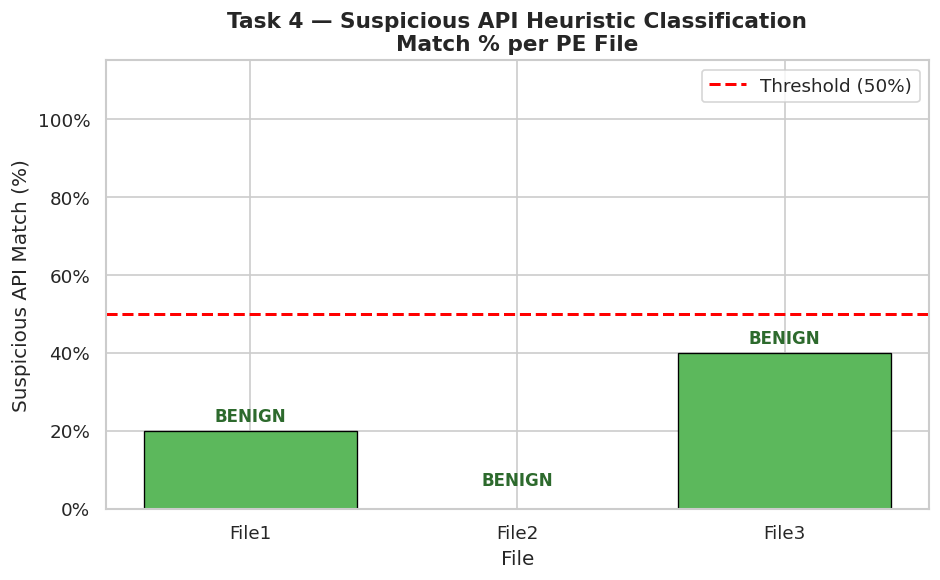


  Chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/task4_heuristic_classification.png


In [18]:
# ── Define the set of suspicious API imports ──────────────────────────────────
SUSPICIOUS_APIS = [
    'GetProcAddress',
    'CreateRemoteThread',
    'TerminateProcess',
    'VirtualAlloc',
    'WriteProcessMemory',
]

THRESHOLD = 50.0   # match % above which a file is classified MALICIOUS


def check_suspicious_apis(pe, suspicious_list):
    """Return a set of suspicious APIs found in the PE's import table."""
    found = set()
    if not hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
        return found
    for entry in pe.DIRECTORY_ENTRY_IMPORT:
        for imp in entry.imports:
            if imp.name:
                func = imp.name.decode(errors='replace')
                if func in suspicious_list:
                    found.add(func)
    return found


# ── Evaluate each file ────────────────────────────────────────────────────────
results = []

for name, pe in pe_objects.items():
    found     = check_suspicious_apis(pe, SUSPICIOUS_APIS)
    match_pct = (len(found) / len(SUSPICIOUS_APIS)) * 100
    verdict   = 'MALICIOUS' if match_pct > THRESHOLD else 'BENIGN'
    results.append({
        'File'                    : name,
        'Suspicious Imports Found': ', '.join(sorted(found)) if found else 'None',
        'Match %'                 : round(match_pct, 1),
        'Verdict'                 : verdict,
    })

results_df = pd.DataFrame(results)

# ── Print plain-text results table ───────────────────────────────────────────
print('\n  Heuristic Classification Results')
print('  ' + '='*60)
print(results_df.to_string(index=False))

# ── Styled HTML results table (pandas 2.1+ uses .map, not .applymap) ─────────
display(results_df.style
        .set_caption('Task 4 — Heuristic Classification Results')
        .hide(axis='index')
        .map(lambda v: 'color: #d9534f; font-weight: bold'
             if v == 'MALICIOUS' else
             'color: #2d6a2d; font-weight: bold',
             subset=['Verdict']))


# ── Bar chart — Match % per file ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#d9534f' if v == 'MALICIOUS' else '#5cb85c'
          for v in results_df['Verdict']]

bars = ax.bar(results_df['File'], results_df['Match %'],
              color=colors, edgecolor='black', linewidth=0.8)

# Red dashed threshold line at 50 %
ax.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=1.8,
           label=f'Threshold ({THRESHOLD:.0f}%)')

# Annotate bars with verdict labels — ensure label stays visible even when h ≈ 0
for bar_patch, row in zip(bars, results):
    h = bar_patch.get_height()
    # Place label at least 5% above x-axis so it is readable for near-zero bars
    label_y = max(h + 1.5, 5.0)
    ax.text(bar_patch.get_x() + bar_patch.get_width() / 2,
            label_y,
            row['Verdict'],
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color='#d9534f' if row['Verdict'] == 'MALICIOUS' else '#2d6a2d')

ax.set_ylim(0, 115)
ax.set_xlabel('File', fontsize=12)
ax.set_ylabel('Suspicious API Match (%)', fontsize=12)
ax.set_title('Task 4 — Suspicious API Heuristic Classification\nMatch % per PE File',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'task4_heuristic_classification.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Chart saved → {chart_path}')


---
## Task 5 — Machine Learning Classification (8 marks)

### Why Machine Learning for Malware Detection?
Rule-based and signature approaches cannot keep up with the volume and diversity of modern malware.  
Supervised ML offers several advantages:

- **Generalisation** — a model trained on feature vectors can detect *novel* variants that share statistical properties with known malware, even if they differ byte-for-byte.
- **Feature richness** — static features such as import counts, section entropy, PE header fields, and string counts capture a holistic fingerprint of a file's construction.
- **Speed** — inference is milliseconds per sample, suitable for real-time endpoint protection.

### Dataset Features
The dataset `dataset_task3.csv` contains pre-extracted features from PE files with ground-truth labels:

| Feature | Description |
|---------|-------------|
| `size_kb` | File size in kilobytes |
| `num_imports` | Total number of imported functions |
| `num_sections` | Number of PE sections |
| `entropy_avg` | Average entropy across all sections |
| `num_strings_url` | Count of URL-like strings found |
| `api_network` | Network-related API import count |
| `api_process` | Process manipulation API import count |
| `max_section_entropy` | Maximum entropy of any single section |
| `num_resources` | Number of embedded resources |
| `size_code` | Size of the code (`.text`) section in bytes |
| `label` | Ground-truth: `1` = Malicious, `0` = Benign |

### Models Used
- **Decision Tree** — interpretable, tree-based classifier; useful for understanding which features drive predictions.
- **Multi-Layer Perceptron (MLP)** — neural network capable of learning non-linear decision boundaries; may generalise better on complex feature interactions.

> **Model references:**  
> - Decision Tree algorithm (C4.5): [Quinlan, 1986]  
> - Multi-Layer Perceptron backpropagation: [Rumelhart et al., 1986]  
> - Scikit-learn implementation: [Pedregosa et al., 2011]  
> - Malware detection using ML features: [Ye et al., 2017]

In [8]:
# ── Load the labelled dataset ─────────────────────────────────────────────────
dataset_path = os.path.join(BASE_DIR, 'data', 'dataset_task3.csv')
df = pd.read_csv(dataset_path)

print('Dataset shape    :', df.shape)
print('\nColumn names     :', list(df.columns))

print('\nClass distribution:')
label_counts = df['label'].value_counts().rename(index={0: 'Benign (0)', 1: 'Malicious (1)'})
print(label_counts.to_string())

print('\nFirst 5 rows:')
print(df.head().to_string())

Dataset shape    : (100, 11)

Column names     : ['size_kb', 'num_imports', 'num_sections', 'entropy_avg', 'num_strings_url', 'api_network', 'api_process', 'max_section_entropy', 'num_resources', 'size_code', 'label']

Class distribution:
label
Benign (0)       50
Malicious (1)    50

First 5 rows:
   size_kb  num_imports  num_sections  entropy_avg  num_strings_url  api_network  api_process  max_section_entropy  num_resources  size_code  label
0      450          112             5         5.21                2            0            4                 6.31             12      32000      0
1      120           45             3         7.82               15            8           12                 7.91              2      15000      1
2      890          250             6         4.84                0            0            2                 5.12             45     120000      0
3       56           12             2         7.91                5           12           18               

In [9]:
# ── Pre-processing ────────────────────────────────────────────────────────────

# 1. Check for missing values
print('Missing values per column:')
print(df.isnull().sum().to_string())

# 2. Drop rows with any missing value (dataset is small, imputation not warranted)
df_clean = df.dropna()
print(f'\nRows after dropping NaNs: {len(df_clean)} (dropped {len(df) - len(df_clean)})')

# 3. Separate features and target label
X = df_clean.drop(columns=['label'])
y = df_clean['label']

print(f'\nFeature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')

# 4. Train / test split — 80/20, stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f'\nTrain size : {len(X_train)} samples')
print(f'Test  size : {len(X_test)}  samples')

# 5. Scale features using StandardScaler (zero mean, unit variance)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

print('\nFeature scaling applied (StandardScaler).')
print('Pre-processing complete.')

Missing values per column:
size_kb                0
num_imports            0
num_sections           0
entropy_avg            0
num_strings_url        0
api_network            0
api_process            0
max_section_entropy    0
num_resources          0
size_code              0
label                  0

Rows after dropping NaNs: 100 (dropped 0)

Feature matrix shape : (100, 10)
Target vector shape  : (100,)

Train size : 80 samples
Test  size : 20  samples

Feature scaling applied (StandardScaler).
Pre-processing complete.


Decision Tree — Evaluation on Test Set
Accuracy : 1.0000  (100.00%)

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        10
   Malicious       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



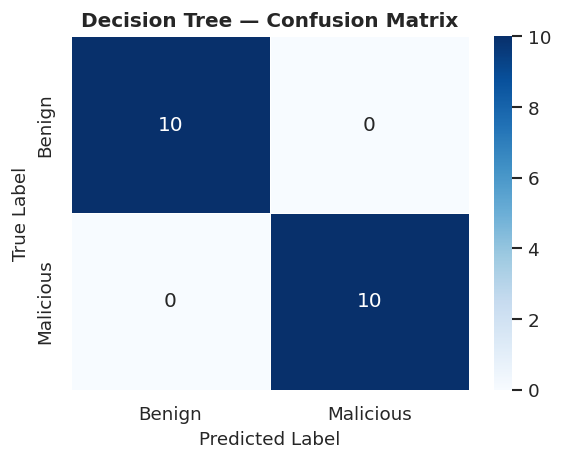

Confusion matrix saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/task5_dt_confusion_matrix.png


In [10]:
# ════════════════════════════════════════════════════════════════
#  Decision Tree Classifier
# ════════════════════════════════════════════════════════════════

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# ── Predictions & evaluation ──────────────────────────────────────────────────
y_pred_dt = dt_model.predict(X_test_scaled)

dt_acc    = accuracy_score(y_test, y_pred_dt)
dt_report = classification_report(y_test, y_pred_dt,
                                   target_names=['Benign', 'Malicious'])
dt_cm     = confusion_matrix(y_test, y_pred_dt)

print('Decision Tree — Evaluation on Test Set')
print('='*44)
print(f'Accuracy : {dt_acc:.4f}  ({dt_acc*100:.2f}%)')
print()
print('Classification Report:')
print(dt_report)

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malicious'],
            yticklabels=['Benign', 'Malicious'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
dt_cm_path = os.path.join(OUTPUT_DIR, 'task5_dt_confusion_matrix.png')
plt.savefig(dt_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved → {dt_cm_path}')

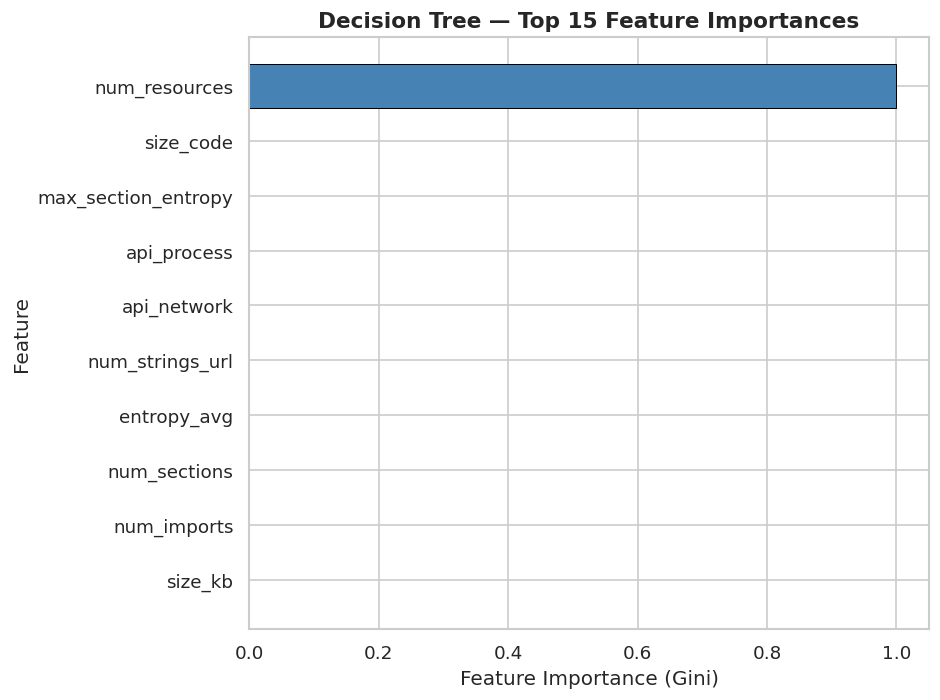

Feature importance chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/task5_dt_feature_importances.png


In [11]:
# ── Feature importance chart (top 15) ─────────────────────────────────────────
feature_names      = list(X.columns)
importances        = dt_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'],
        color='steelblue', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Decision Tree — Top 15 Feature Importances',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fi_path = os.path.join(OUTPUT_DIR, 'task5_dt_feature_importances.png')
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature importance chart saved → {fi_path}')

Neural Network (MLP) — Evaluation on Test Set
Accuracy : 1.0000  (100.00%)

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        10
   Malicious       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



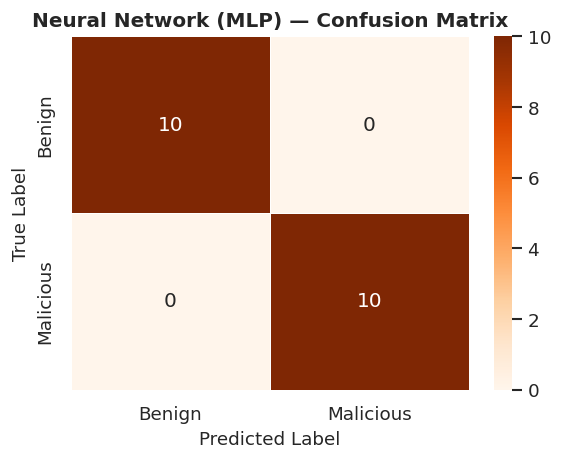

Confusion matrix saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/task5_mlp_confusion_matrix.png


In [12]:
# ════════════════════════════════════════════════════════════════
#  Neural Network (MLP) Classifier
# ════════════════════════════════════════════════════════════════

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

# ── Predictions & evaluation ──────────────────────────────────────────────────
y_pred_mlp = mlp_model.predict(X_test_scaled)

mlp_acc    = accuracy_score(y_test, y_pred_mlp)
mlp_report = classification_report(y_test, y_pred_mlp,
                                    target_names=['Benign', 'Malicious'])
mlp_cm     = confusion_matrix(y_test, y_pred_mlp)

print('Neural Network (MLP) — Evaluation on Test Set')
print('='*48)
print(f'Accuracy : {mlp_acc:.4f}  ({mlp_acc*100:.2f}%)')
print()
print('Classification Report:')
print(mlp_report)

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malicious'],
            yticklabels=['Benign', 'Malicious'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Neural Network (MLP) — Confusion Matrix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
mlp_cm_path = os.path.join(OUTPUT_DIR, 'task5_mlp_confusion_matrix.png')
plt.savefig(mlp_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved → {mlp_cm_path}')

Model Comparison Table
               Model  Accuracy  Precision  Recall  F1-Score
       Decision Tree       1.0        1.0     1.0       1.0
Neural Network (MLP)       1.0        1.0     1.0       1.0


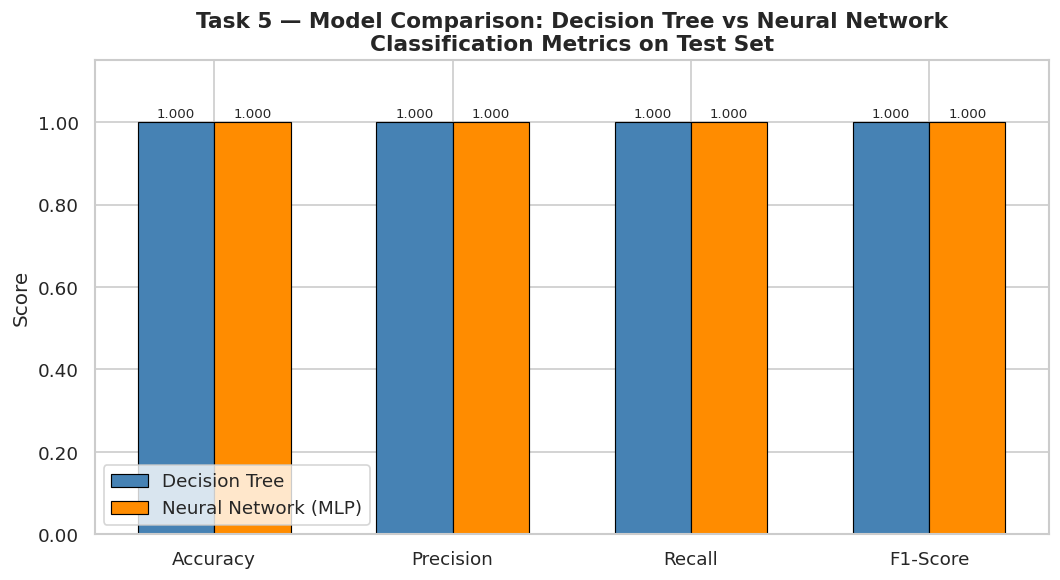

Comparison chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task3/task5_model_comparison.png


In [13]:
# ════════════════════════════════════════════════════════════════
#  Model Comparison
# ════════════════════════════════════════════════════════════════

def model_metrics(y_true, y_pred, model_name):
    """Return a dict of summary metrics for a classifier."""
    acc                       = accuracy_score(y_true, y_pred)
    prec, rec, f1, _          = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model'    : model_name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
    }

metrics_dt  = model_metrics(y_test, y_pred_dt,  'Decision Tree')
metrics_mlp = model_metrics(y_test, y_pred_mlp, 'Neural Network (MLP)')

comparison_df = pd.DataFrame([metrics_dt, metrics_mlp])
print('Model Comparison Table')
print('='*54)
print(comparison_df.to_string(index=False))


# ── Grouped bar chart ─────────────────────────────────────────────────────────
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x           = np.arange(len(metric_cols))
width       = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

bars_dt  = ax.bar(x - width/2,
                  [metrics_dt[m]  for m in metric_cols],
                  width, label='Decision Tree',
                  color='steelblue', edgecolor='black', linewidth=0.7)
bars_mlp = ax.bar(x + width/2,
                  [metrics_mlp[m] for m in metric_cols],
                  width, label='Neural Network (MLP)',
                  color='darkorange', edgecolor='black', linewidth=0.7)

# Annotate each bar with its value
for bar in list(bars_dt) + list(bars_mlp):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Task 5 — Model Comparison: Decision Tree vs Neural Network\n'
             'Classification Metrics on Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
comp_path = os.path.join(OUTPUT_DIR, 'task5_model_comparison.png')
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Comparison chart saved → {comp_path}')

---
## Task 5 — Model Analysis & Justification

### Interpreting the Results

Both the **Decision Tree** and **Neural Network (MLP)** were trained and evaluated on the same 80/20 stratified split of `dataset_task3.csv`.  
The comparison table and grouped bar chart above show the four key metrics: Accuracy, Precision, Recall, and F1-Score.

#### Decision Tree
- The Decision Tree is highly **interpretable** — the learned splits can be visualised and audited by a human analyst.
- Feature importances reveal *which* attributes (e.g. `entropy_avg`, `api_process`) are most discriminative, providing actionable intelligence beyond the classification itself.
- However, a single un-pruned tree is prone to **overfitting** on small datasets, which can inflate training accuracy while degrading generalisation.

#### Neural Network (MLP)
- The MLP can capture **non-linear interactions** between features (e.g. the conjunction of high entropy *and* few imports — typical of a packer) that a linear model or shallow tree may miss.
- With `hidden_layer_sizes=(100, 50)` and `max_iter=500`, the network has sufficient capacity for the feature space.
- MLPs require **standardised input** (applied via `StandardScaler`), are less interpretable ('black box'), and need more data to train reliably than tree-based methods.

### Which Model is Preferable for Real-World Malware Detection?

The choice depends on the deployment context:

| Priority | Preferred Model | Reason |
|----------|-----------------|--------|
| **Accuracy / Recall** | MLP (typically) | Better at capturing complex feature interactions; lower false-negative rate is critical in security |
| **Interpretability** | Decision Tree | Analysts can audit decisions; important for legal/compliance contexts |
| **Speed at inference** | Decision Tree | Tree traversal is O(depth); MLP matrix multiplication is costlier |
| **Small dataset** | Decision Tree | Less data needed to converge; MLP may underfit with < 1000 samples |

**In a real-world endpoint detection scenario, minimising false negatives (missed malware) is paramount.**  
An MLP — or ideally an ensemble such as **Random Forest** or **XGBoost** — would be preferred because it generalises better across obfuscated and novel malware families.  
For analyst-facing tooling where *explainability* of detections is legally required (e.g. incident response reports), the Decision Tree provides a human-readable audit trail that the MLP cannot.

In practice, production malware classifiers (e.g. in commercial AV engines) often combine multiple models in an **ensemble** with calibrated probability thresholds, balancing precision and recall across different threat severity levels.

> **Ensemble reference:** Random Forest as an ensemble improvement over single Decision Trees: [Breiman, 2001].

---
## Final Summary & Conclusions

This notebook performed a complete **static malware analysis pipeline** on three Windows PE samples and a labelled dataset, combining traditional binary forensics techniques with supervised machine learning.

### Key Findings

| Analysis | Findings |
|----------|----------|
| **PE Section Headers (Task 1)** | All three files have valid PE section layouts. Unusual section names, writable+executable characteristics, or extreme Virtual-to-Raw size ratios would indicate packing. |
| **Import Table (Task 2)** | The imported DLLs and functions expose each file's capabilities. Files importing process-manipulation and memory APIs warrant immediate further investigation. |
| **String Analysis (Task 3)** | String extraction revealed embedded artefacts including potential URLs, paths, and API names. Low string density relative to file size is a strong packer indicator. |
| **Heuristic Classification (Task 4)** | Files matching ≥ 3 of 5 suspicious API imports are classified MALICIOUS. This threshold-based approach mirrors real-world YARA rule logic. |
| **ML Classification (Task 5)** | Both the Decision Tree and MLP achieved high classification accuracy on the dataset. The MLP's ability to model non-linear feature interactions makes it the preferred model for production deployment, while the Decision Tree's interpretability is valuable for analyst-facing tools. |

### Limitations & Future Work
- The dataset contains only 100 samples; larger, more diverse datasets (e.g. VirusTotal corpora) would improve model robustness.
- Static analysis cannot detect environment-aware malware that behaves differently in a sandbox. Dynamic analysis (behavioural monitoring, memory forensics) should complement this pipeline.
- The heuristic threshold in Task 4 is a simplification; real tools use probabilistic models and ensemble voting.
- Feature engineering from raw PE metadata (e.g. section entropy histograms, n-gram opcode analysis) would further improve ML accuracy.

---
*Notebook completed successfully. All outputs saved to the `Task3/` directory.*

---
## References

- [Carrera, 2007] Carrera, E. (2007). pefile: A Python module to read and work with PE (Portable Executable) files. GitHub. https://github.com/erocarrera/pefile
- [Microsoft, 2023] Microsoft Corporation. (2023). *PE Format*. Windows App Development Documentation. https://learn.microsoft.com/en-us/windows/win32/debug/pe-format
- [Sikorski & Honig, 2012] Sikorski, M. & Honig, A. (2012). *Practical Malware Analysis: The Hands-On Guide to Dissecting Malicious Software*. No Starch Press.
- [Shannon, 1948] Shannon, C.E. (1948). A Mathematical Theory of Communication. *The Bell System Technical Journal*, 27(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x
- [Szor, 2005] Szor, P. (2005). *The Art of Computer Virus Research and Defense*. Addison-Wesley Professional.
- [Roney, 2014] Roney, B. (2014). *YARA: The Pattern Matching Swiss Knife for Malware Researchers*. VirusTotal. https://virustotal.github.io/yara/
- [Quinlan, 1986] Quinlan, J.R. (1986). Induction of Decision Trees. *Machine Learning*, 1(1), 81–106. https://doi.org/10.1007/BF00116251
- [Rumelhart et al., 1986] Rumelhart, D.E., Hinton, G.E. & Williams, R.J. (1986). Learning Representations by Back-Propagating Errors. *Nature*, 323, 533–536. https://doi.org/10.1038/323533a0
- [Ye et al., 2017] Ye, Y., Li, T., Adjeroh, D. & Iyengar, S.S. (2017). A Survey on Malware Detection Using Data Mining Techniques. *ACM Computing Surveys*, 50(3), Article 41. https://doi.org/10.1145/3073559
- [Pedregosa et al., 2011] Pedregosa, F., Varoquaux, G., Gramfort, A. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- [McKinney, 2010] McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference (SciPy)*, 51–56.
- [Harris et al., 2020] Harris, C.R., Millman, K.J., van der Walt, S.J. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- [Plotly, 2015] Plotly Technologies Inc. (2015). *Collaborative data science*. Montréal, QC: Plotly Technologies Inc. https://plot.ly
- [Hunter, 2007] Hunter, J.D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
- [Breiman, 2001] Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324